# Integrantes

* Centeno Amado Eduardo
* Orozpe Frias Erick Adrian
* Pineda Gaona Maricruz
* Rodriguez Teodores Armando
* Velasco Martell Dayra

# Librerías

In [ ]:
# Sistema
import os

# Análisis y manipulación de datos
import numpy as np
import pandas as pd

from scipy.stats import uniform

# Manejo de texto plano
import re
import emoji
import unicodedata

# Nube de palabras
from wordcloud import WordCloud, STOPWORDS

# Análisis de texto
import spacy
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo de regresión logítica y Bayes
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Búsqueda de hiper-parámetros, train test, métricas
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer
from sklearn.svm import LinearSVC

# Guardar modelo y pipeline
import pickle
from sklearn.pipeline import make_pipeline

# IMDB Reviews — Clasificación de reseñas

* Realiza **análisis de texto** para posteriormente **clasificar reseñas** de IMDB.
* **Datos**: descarga el dataset desde [https://ai.stanford.edu/~amaas/data/sentiment/](https://ai.stanford.edu/~amaas/data/sentiment/).
* Las reseñas ya están **divididas en train/test**; encuentra la forma de **leerlas**.
* **Modelos a comparar**:

  * Clasificador **bayesiano**,
  * **Regresión logística**,
  * **SVM** con **kernel lineal**,
    y selecciona el **mejor modelo**.
* **Nota**: si procesas texto con **spaCy**, puede tardar por el volumen de datos; considera dejar esos pasos corriendo mientras haces otras actividades.

## Tratamiento de Datos

In [41]:
root = "../Datasets/aclImdb"   # <- adjust to your local path

rows = []
for dirpath, dirnames, filenames in os.walk(root):
    # Expect paths like .../aclImdb/train/pos/xxxxx_7.txt
    parts = dirpath.split(os.sep)
    if len(parts) < 2: 
        continue

    split = "train" if "train" in parts else ("test" if "test" in parts else None)
    label = 1 if "pos" in parts else (0 if "neg" in parts else None)
    if split is None or label is None:
        continue  # skip e.g. unsup and other folders

    for fn in filenames:
        if not fn.endswith(".txt"):
            continue
        # filename pattern: "<id>_<rating>.txt"
        stem = fn[:-4]
        if "_" not in stem:
            continue
        id_str, rating_str = stem.split("_", 1)
        path = os.path.join(dirpath, fn)
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read().replace("<br />", " ")
        rows.append({
            #"path": path,
            "split": split, # train | test
            "label": label, # 1 pos | 0 neg
            "text": text,
            "rating": int(rating_str),
            "id": int(id_str)
        })

df = pd.DataFrame(rows)

display(df.head())
print(df.shape)

,split,label,text,rating,id
0,train,1,The Running Man is one of those films that if ...,7,5349
1,train,1,"This is a great, ridiculous horror movie that ...",9,5973
2,train,1,"I have to agree with MR. Caruso Jr Lanza,s was...",10,10419
3,train,1,Something happens to Sondra Pransky when she e...,8,11951
4,train,1,I had never heard of this film prior to seeing...,7,9370


(50000, 5)


**Run In Terminal**

`pip install -U spacy`

`python -m spacy download en_core_web_sm`

In [73]:
nlp = spacy.load("en_core_web_sm")
stop_words = nlp.Defaults.stop_words

In [83]:
print(list(stop_words)[:10])

['get', 'otherwise', 'thereby', 'these', 'how', 'hundred', 'did', 'sometime', 'his', 'serious']


In [84]:
def clean_text(s: str) -> str:
    s = s.replace("<br />", " ")                  # remove HTML line breaks
    s = re.sub(r"<[^>]+>", " ", s)                # just in case, drop any other tags
    s = re.sub(r"\s+", " ", s).strip()            # normalize whitespace
    s = s.lower()
    doc = nlp(s)

    #Filtrar tokens válidos
    tokens = [
        token.lemma_
        for token in doc
            if not token.is_stop          # remove stopwords
            and not token.is_punct        # remove punctuation
            and token.is_alpha            # keep short words
            and len(token) > 2            # evitar tokens muy cortos
    ]
    
    return tokens if tokens else None

In [85]:
df['text_clean'] = df['text'].map(clean_text)

In [89]:
df.rename(columns={'text_clean': 'tokens'}, inplace=True)

In [99]:
# Eliminar filas sin tokens

if df['tokens'].isna().sum() > 0:
    df = df.dropna(subset=["tokens"]).reset_index(drop=True)
else:
    print("NO hay valores nulos.")

NO hay valores nulos.


In [105]:
if df['tokens'].apply(lambda x: len(x) == 0).sum() > 0:
    df = df.loc[df['tokens'].apply(lambda x: len(x) > 0)]
else:
    print('NO hay tokens vacíos.')

NO hay tokens vacíos.


In [107]:
# Definimos una lista de todas las palabras

all_words = [word for tokens in df["tokens"] for word in tokens]
freq = Counter(all_words)

In [115]:
# Definimos los hapaxes (palabras que solo aparecen 1 vez)

hapaxes = {word: count for word, count in freq.items() if count == 1}

In [111]:
# Función para eliminar hapaxes

def remove_hapaxes(tokens):
    global hapaxes
    return [t for t in tokens if t not in hapaxes]

In [117]:
tokens_copy = df['tokens'].copy() # Respaldo

In [127]:
df['tokens'] = tokens_copy.map(remove_hapaxes)

In [128]:
df.columns

Index(['split', 'label', 'text', 'rating', 'id', 'tokens'], dtype='object')

In [129]:
# Crear columna de texto limpio (para WordCloud y TF-IDF)

df["text_clean"] = df["tokens"].apply(lambda x: " ".join(x))

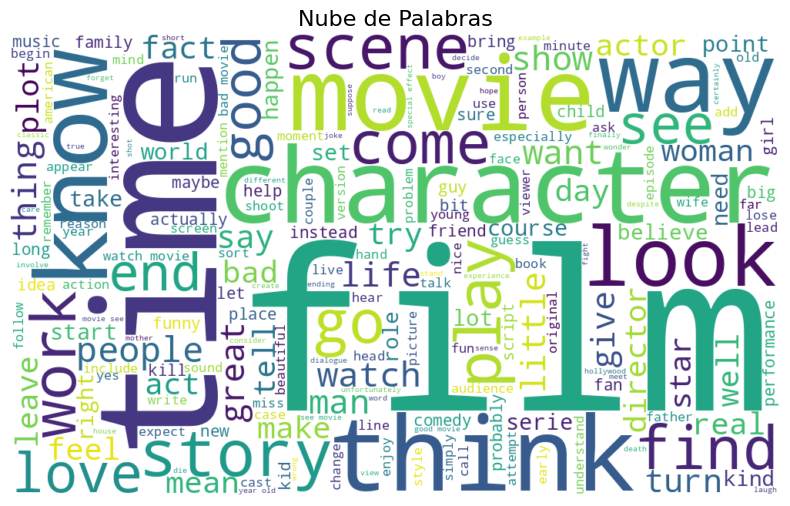

In [133]:
# Nos saltamos el paso de normalizar porque en inglés no existen los acentos

texto_total = " ".join(df["text_clean"].tolist())

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis"
).generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras", fontsize=16)
plt.show()

In [134]:
df.head()

,split,label,text,rating,id,tokens,text_clean
0,train,1,The Running Man is one of those films that if ...,7,5349,"[run, man, film, overwatche, boring, depressin...",run man film overwatche boring depressing advi...
1,train,1,"This is a great, ridiculous horror movie that ...",9,5973,"[great, ridiculous, horror, movie, capture, es...",great ridiculous horror movie capture essence ...
2,train,1,"I have to agree with MR. Caruso Jr Lanza,s was...",10,10419,"[agree, caruso, lanza, fine, voice, god, offer...",agree caruso lanza fine voice god offer find c...
3,train,1,Something happens to Sondra Pransky when she e...,8,11951,"[happen, sondra, pransky, enter, magician, box...",happen sondra pransky enter magician box stage...
4,train,1,I had never heard of this film prior to seeing...,7,9370,"[hear, film, prior, see, wonder, independent, ...",hear film prior see wonder independent film co...


In [140]:
X_train = df.loc[df["split"]=="train", "text_clean"]
y_train = df.loc[df["split"]=="train", "label"]

X_test  = df.loc[df["split"]=="test",  "text_clean"]
y_test  = df.loc[df["split"]=="test",  "label"]

In [153]:
# Vectorizamos

"""tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2), 
    min_df= 0.001,
    max_df=0.7,
    stop_words=None
)"""

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=None,
    lowercase=False,        # ya se hizo .lower()
    stop_words=None,        # ya no hay stopwords
    strip_accents="unicode",
    sublinear_tf=True,
    dtype=np.float32
)

In [154]:
# Ajustamos con el train y transformamos ambos

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [155]:
print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape:  {X_test_tfidf.shape}")

Train shape: (25000, 78113)
Test shape:  (25000, 78113)


## Bayes Classifier

In [199]:
def evaluate_model(model, X, y, dataset_name="Dataset"):
    # 1) Obtener "scores" y umbral por defecto según el tipo de modelo
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X)[:, 1]
        default_thr = 0.5
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        default_thr = 0.0          # frontera de decisión en SVM lineal
    else:
        # fallback mínimo: solo métricas con predicción discreta
        y_pred = model.predict(X)
        cm = confusion_matrix(y, y_pred)
        acc = accuracy_score(y, y_pred)
        sens = recall_score(y, y_pred)
        spec = cm[0,0] / (cm[0,0] + cm[0,1])
        print(f"\n=== Resultados en {dataset_name} (sin scores) ===")
        print(f"Accuracy: {acc:.4f}  Sens: {sens:.4f}  Esp: {spec:.4f}")
        print("AUC/ROC no disponible (el modelo no da scores).")
        return

    # 2) Métricas con umbral por defecto
    y_pred_default = (scores >= default_thr).astype(int)
    cm = confusion_matrix(y, y_pred_default)
    acc = accuracy_score(y, y_pred_default)
    sens = recall_score(y, y_pred_default)
    spec = cm[0,0] / (cm[0,0] + cm[0,1])
    auc = roc_auc_score(y, scores)

    print(f"\n=== Resultados en {dataset_name} (umbral = {default_thr:.2f}) ===")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Sensibilidad:  {sens:.4f}")
    print(f"Especificidad: {spec:.4f}")
    print(f"AUC:           {auc:.4f}")

    # 3) Umbral óptimo (Youden J) + curva ROC
    fpr, tpr, thresholds = roc_curve(y, scores)
    specificity = 1 - fpr
    J = tpr + specificity - 1
    idx_opt = np.argmax(J)
    best_threshold = thresholds[idx_opt]

    print(f"\n--- Calibración Youden J ---")
    print(f"Umbral óptimo:        {best_threshold:.4f}")
    print(f"Sensibilidad óptima:  {tpr[idx_opt]:.4f}")
    print(f"Especificidad óptima: {specificity[idx_opt]:.4f}")

    # 4) Métricas con umbral óptimo
    y_pred_opt = (scores >= best_threshold).astype(int)
    cm_opt = confusion_matrix(y, y_pred_opt)
    acc_opt = accuracy_score(y, y_pred_opt)
    sens_opt = recall_score(y, y_pred_opt)
    spec_opt = cm_opt[0,0] / (cm_opt[0,0] + cm_opt[0,1])

    print(f"\n=== Resultados en {dataset_name} (umbral óptimo) ===")
    print(f"Accuracy:      {acc_opt:.4f}")
    print(f"Sensibilidad:  {sens_opt:.4f}")
    print(f"Especificidad: {spec_opt:.4f}")

    # 5) Curva ROC
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{dataset_name} (AUC={auc:.4f})")
    plt.plot([0,1], [0,1], "k--")
    plt.scatter(fpr[idx_opt], tpr[idx_opt], color='red', label=f"Umbral óptimo={best_threshold:.3f}")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {dataset_name}")
    plt.legend(); plt.show()

In [160]:
# Creamos un grid para el mejor alpha
param_grid = {"alpha": np.logspace(-3, 1, 10)}  # valores desde 0.001 hasta 10
grid = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

,estimator,MultinomialNB()
,param_grid,{'alpha': array([1.0000...00000000e+01])}
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.46415888336127775


In [161]:
best_alpha = grid.best_params_["alpha"]
print(f"Mejor alfa encontrado: {best_alpha:.4f}")

Mejor alfa encontrado: 0.4642


In [162]:
# Modelo final
nb = MultinomialNB(alpha=best_alpha)
nb.fit(X_train_tfidf, y_train)

,alpha,0.46415888336127775
,force_alpha,True
,fit_prior,True
,class_prior,None


In [163]:
 #Validación cruzada
cv_scores = cross_val_score(nb, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.8751
Mediana: 0.8762
Desviación estándar: 0.0022



=== Resultados en Train (umbral = 0.50) ===
Accuracy:      0.9377
Sensibilidad:  0.9405
Especificidad: 0.9350
AUC:           0.9840

--- Calibración Youden J ---
Umbral óptimo:        0.5070
Sensibilidad óptima:  0.9386
Especificidad óptima: 0.9377

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.9381
Sensibilidad:  0.9386
Especificidad: 0.9377


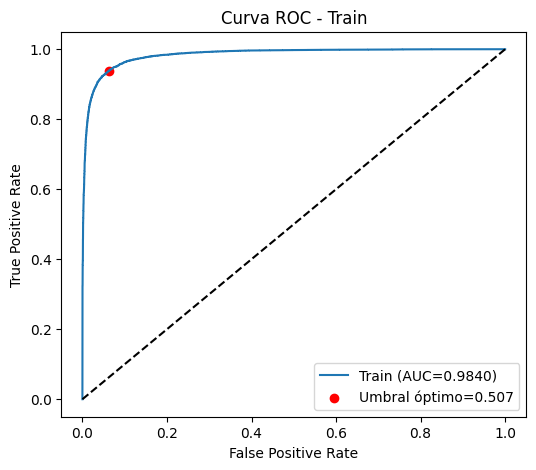


=== Resultados en Test (umbral = 0.50) ===
Accuracy:      0.8505
Sensibilidad:  0.8277
Especificidad: 0.8733
AUC:           0.9289

--- Calibración Youden J ---
Umbral óptimo:        0.4533
Sensibilidad óptima:  0.8643
Especificidad óptima: 0.8434

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.8538
Sensibilidad:  0.8643
Especificidad: 0.8434


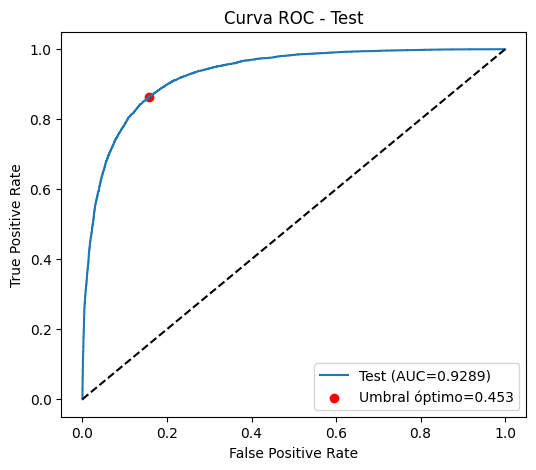

In [201]:
evaluate_model(nb, X_train_tfidf, y_train, "Train")
evaluate_model(nb, X_test_tfidf, y_test, "Test")

## Regresión Logística

In [172]:
# Modelo base (más fácil de que converja)
log_reg = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    max_iter=2000,   # 5000 no ayuda si el C es muy grande
    tol=1e-3,        # tolerancia menos estricta acelera
)

# Distribución más pequeña (evita C enormes)
param_dist = {
    "C": np.logspace(-2, 2, 12),          # 1e-2 ... 1e2
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9] # discretiza; suficiente
}

# Búsqueda más barata
log_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=12,       # en vez de 30
    cv=3,            # en vez de 5
    scoring="accuracy",
    random_state=1989,
    n_jobs=-1,
    verbose=1
)

In [173]:
log_search.fit(X_train_tfidf, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,LogisticRegre... tol=0.001)
,param_distributions,"{'C': array([1.0000...00000000e+02]), 'l1_ratio': [0.1, 0.3, ...]}"
,n_iter,12
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,1989
,error_score,nan


In [174]:
# Mejores parámetros

best_log = log_search.best_estimator_
print("Mejores parámetros Logistic Regression:", log_search.best_params_)

Mejores parámetros Logistic Regression: {'l1_ratio': 0.1, 'C': 18.73817422860385}


In [175]:
best_c = log_search.best_params_["C"]
best_l1 = log_search.best_params_["l1_ratio"]

In [178]:
# Mejor modelo
best_reglog = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    max_iter=2000,   # 5000 no ayuda si el C es muy grande
    tol=1e-3,        # tolerancia menos estricta acelera
    C = best_c,
    l1_ratio = best_l1
)

In [179]:
best_reglog.fit(X_train_tfidf, y_train)

,penalty,'elasticnet'
,dual,False
,tol,0.001
,C,18.73817422860385
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


In [180]:
# Validación cruzada
cv_scores = cross_val_score(best_reglog, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.8924
Mediana: 0.8916
Desviación estándar: 0.0037



=== Resultados en Train (umbral = 0.50) ===
Accuracy:      0.9997
Sensibilidad:  0.9997
Especificidad: 0.9998
AUC:           1.0000

--- Calibración Youden J ---
Umbral óptimo:        0.4908
Sensibilidad óptima:  0.9998
Especificidad óptima: 0.9998

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.9998
Sensibilidad:  0.9998
Especificidad: 0.9998


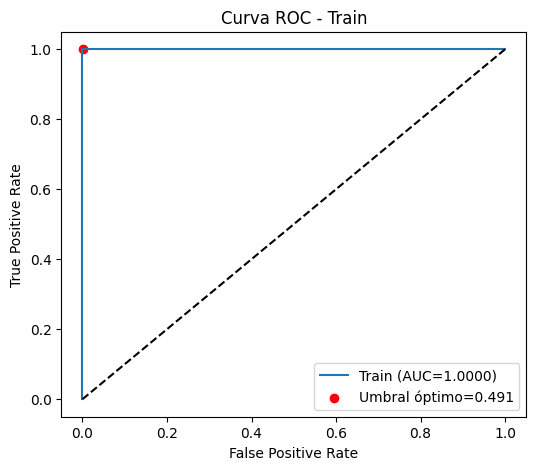


=== Resultados en Test (umbral = 0.50) ===
Accuracy:      0.8785
Sensibilidad:  0.8723
Especificidad: 0.8847
AUC:           0.9507

--- Calibración Youden J ---
Umbral óptimo:        0.4454
Sensibilidad óptima:  0.8919
Especificidad óptima: 0.8674

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.8797
Sensibilidad:  0.8919
Especificidad: 0.8674


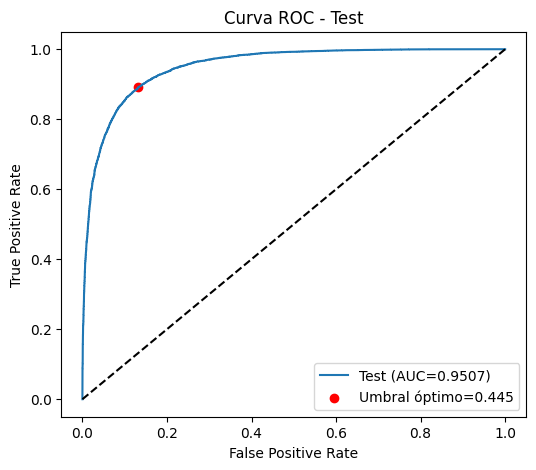

In [202]:
# Evaluación del rendimiento
evaluate_model(best_reglog, X_train_tfidf, y_train, "Train")
evaluate_model(best_reglog, X_test_tfidf, y_test, "Test")

## Linear SVC

In [190]:
def train_linear_svc(Xtr, ytr, cv=3):
    base = LinearSVC(
        max_iter=10000,   # ↑ iteraciones
        tol=1e-3,         # tolerancia menos estricta
        dual=True,        # mejor cuando n_features >> n_samples
        loss="squared_hinge"
    )
    grid = {"C": np.logspace(-3, 2, 11)}  # 1e-3 ... 1e2 (sin 1e3)
    gs = GridSearchCV(base, grid, cv=cv, n_jobs=-1, scoring="accuracy", verbose=1)
    gs.fit(Xtr, ytr)
    return gs.best_estimator_, gs.best_params_

In [191]:
svm_best, svm_params = train_linear_svc(X_train_tfidf, y_train, cv=3)

Fitting 3 folds for each of 11 candidates, totalling 33 fits


In [194]:
# Validación cruzada
cv_scores = cross_val_score(svm_best, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.8940
Mediana: 0.8938
Desviación estándar: 0.0038



=== Resultados en Train (umbral = 0.00) ===
Accuracy:      0.9811
Sensibilidad:  0.9836
Especificidad: 0.9786
AUC:           0.9980

--- Calibración Youden J ---
Umbral óptimo:        0.0349
Sensibilidad óptima:  0.9800
Especificidad óptima: 0.9834

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.9817
Sensibilidad:  0.9800
Especificidad: 0.9834


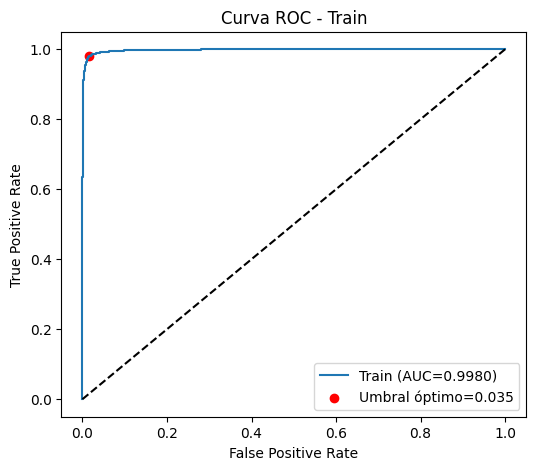


=== Resultados en Test (umbral = 0.00) ===
Accuracy:      0.8840
Sensibilidad:  0.8826
Especificidad: 0.8854
AUC:           0.9532

--- Calibración Youden J ---
Umbral óptimo:        -0.0071
Sensibilidad óptima:  0.8858
Especificidad óptima: 0.8833

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.8845
Sensibilidad:  0.8858
Especificidad: 0.8833


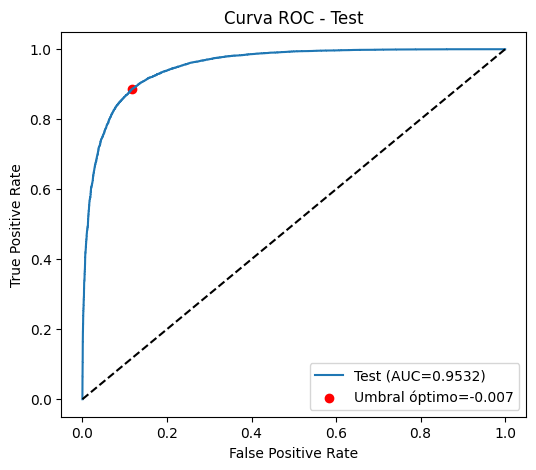

In [203]:
# Para LinearSVC (usa decision_function)
evaluate_model(svm_best, X_train_tfidf, y_train, "Train")
evaluate_model(svm_best, X_test_tfidf,  y_test,  "Test")

In [206]:
def results_model(model, X, y, model_name: str, dataset_name="Dataset"):
    # 1) Obtener "scores" y umbral por defecto según el tipo de modelo
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X)[:, 1]
        default_thr = 0.5
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        default_thr = 0.0          # frontera de decisión en SVM lineal
    else:
        # fallback mínimo: solo métricas con predicción discreta
        y_pred = model.predict(X)
        cm = confusion_matrix(y, y_pred)
        acc = accuracy_score(y, y_pred)
        sens = recall_score(y, y_pred)
        spec = cm[0,0] / (cm[0,0] + cm[0,1])
        print(f"\n=== Resultados en {dataset_name} (sin scores) ===")
        print(f"Accuracy: {acc:.4f}  Sens: {sens:.4f}  Esp: {spec:.4f}")
        print("AUC/ROC no disponible (el modelo no da scores).")
        return

    # 2) Métricas con umbral por defecto
    y_pred_default = (scores >= default_thr).astype(int)
    cm = confusion_matrix(y, y_pred_default)
    acc = accuracy_score(y, y_pred_default)
    sens = recall_score(y, y_pred_default)
    spec = cm[0,0] / (cm[0,0] + cm[0,1])
    auc = roc_auc_score(y, scores)

    """print(f"\n=== Resultados en {dataset_name} (umbral = {default_thr:.2f}) ===")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Sensibilidad:  {sens:.4f}")
    print(f"Especificidad: {spec:.4f}")
    print(f"AUC:           {auc:.4f}")"""

    # 3) Umbral óptimo (Youden J) + curva ROC
    fpr, tpr, thresholds = roc_curve(y, scores)
    specificity = 1 - fpr
    J = tpr + specificity - 1
    idx_opt = np.argmax(J)
    best_threshold = thresholds[idx_opt]

    """print(f"\n--- Calibración Youden J ---")
    print(f"Umbral óptimo:        {best_threshold:.4f}")
    print(f"Sensibilidad óptima:  {tpr[idx_opt]:.4f}")
    print(f"Especificidad óptima: {specificity[idx_opt]:.4f}")"""

    # 4) Métricas con umbral óptimo
    y_pred_opt = (scores >= best_threshold).astype(int)
    cm_opt = confusion_matrix(y, y_pred_opt)
    acc_opt = accuracy_score(y, y_pred_opt)
    sens_opt = recall_score(y, y_pred_opt)
    spec_opt = cm_opt[0,0] / (cm_opt[0,0] + cm_opt[0,1])

    """print(f"\n=== Resultados en {dataset_name} (umbral óptimo) ===")
    print(f"Accuracy:      {acc_opt:.4f}")
    print(f"Sensibilidad:  {sens_opt:.4f}")
    print(f"Especificidad: {spec_opt:.4f}")"""

    """# 5) Curva ROC
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{dataset_name} (AUC={auc:.4f})")
    plt.plot([0,1], [0,1], "k--")
    plt.scatter(fpr[idx_opt], tpr[idx_opt], color='red', label=f"Umbral óptimo={best_threshold:.3f}")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {dataset_name}")
    plt.legend(); plt.show()"""

    return {
        "Model": model_name,
        "Split": dataset_name, 
        "Accuracy": acc_opt, 
        "Sensibilidad": sens_opt, 
        "Especificidad": spec_opt,
        "AUC": auc,
        "Best Umbral": best_threshold
    }

In [207]:
resultados = [
    results_model(nb, X_train_tfidf, y_train, "Bayessiano", "Train"),
    results_model(nb, X_test_tfidf,  y_test,  "Bayessiano", "Test"),
    results_model(best_reglog, X_train_tfidf, y_train, "Reg Log", "Train"),
    results_model(best_reglog, X_test_tfidf,  y_test,  "Reg Log", "Test"),
    results_model(svm_best, X_train_tfidf, y_train, "SVM", "Train"),
    results_model(svm_best, X_test_tfidf,  y_test,  "SVM", "Test")
]

In [208]:
pd.DataFrame(resultados)

,Model,Split,Accuracy,Sensibilidad,Especificidad,AUC,Best Umbral
0,Bayessiano,Train,0.93812,0.93856,0.93768,0.983976,0.506978
1,Bayessiano,Test,0.85384,0.86432,0.84336,0.928901,0.453252
2,Reg Log,Train,0.99976,0.99976,0.99976,1.000000,0.490783
3,Reg Log,Test,0.87968,0.89192,0.86744,0.950685,0.445355
4,SVM,Train,0.98172,0.98000,0.98344,0.997994,0.034879
5,SVM,Test,0.88452,0.88576,0.88328,0.953218,-0.007053


* El SVM lineal obtuvo mayor AUC y accuracy en test
* La Regresión Logística maximizó la sensibilidad
* Seleccionamos SVM como mejor modelo por desempeño global (AUC/accuracy) y guardamos el pipeline + umbral óptimo para despliegue.

## Guardar Mejor Modelo (Pipeline completo)

In [209]:
svm_final = make_pipeline(tfidf, svm_best)  # usa el tfidf ajustado a TRAIN y el mejor SVM

scores_tr = svm_final.decision_function(df.loc[df.split=="train","text_clean"])
y_tr = df.loc[df.split=="train","label"].values
fpr, tpr, thr = roc_curve(y_tr, scores_tr)
youden = tpr - (1 - fpr)
thr_opt = float(thr[np.argmax(youden)])

bundle = {"pipeline": svm_final, "threshold": thr_opt}

with open("best_svm_imdb.pkl", "wb") as f:
    pickle.dump(bundle, f)

## Carga del mejor modelo (posterior)

In [ ]:
with open("best_svm_imdb.pkl", "rb") as f:
    bundle = pickle.load(f)

pipe = bundle["pipeline"]
thr  = bundle["threshold"]

def predict_labels(texts):
    scores = pipe.decision_function(texts)   # LinearSVC
    return (scores >= thr).astype(int)

# y_pred = predict_labels(["great movie!", "awful plot..."])

# Demanda de ecobicis — Predicción con SVR

* **Datos**: utiliza el dataset **Seoul Bike Sharing Demand** (bicicletas rentadas en Seúl) de UCI ML Repository: [https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand).
* Construye un **modelo de regresión** con **cada uno de los kernels de SVR**, usando como **variable objetivo** `Rented Bike Count`.
* Tras el **análisis de datos**, **encuentra tu mejor modelo** y **compara y concluye**.